# Import Dependcies

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, classification_report, roc_auc_score

# Data Cleaning

In [2]:
df = pd.read_csv("/Users/alvislow/repos/DSA3101/bank_customers_train.csv")
print(df.head())
print(len(df))
print(df.isnull().sum())


   age          job   marital          education default housing loan  \
0   35  blue-collar    single        high.school     NaN      no   no   
1   52  blue-collar   married                NaN     NaN     yes   no   
2   38     services   married        high.school     NaN      no   no   
3   44       admin.   married  university.degree      no     yes   no   
4   25     services  divorced           basic.4y      no     yes   no   

     contact month day_of_week  ...  campaign  pdays  previous     poutcome  \
0   cellular   jul         thu  ...         3    999         0  nonexistent   
1  telephone   jun         thu  ...         4    999         0  nonexistent   
2  telephone   jun         tue  ...         2    999         0  nonexistent   
3  telephone   oct         wed  ...         1    999         0  nonexistent   
4  telephone   may         fri  ...         1    999         0  nonexistent   

  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed    y  
0        

In [3]:
df = df.dropna(subset=['housing', 'loan', 'marital', 'education', 'job', ])
print(df.isnull().sum())
print(df.shape)

age                  0
job                  0
marital              0
education            0
default           7354
housing              0
loan                 0
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64
(36381, 21)


In [4]:
for column in df.columns:
    print(f"Unique values in {column}:")
    print(df[column].unique())
    print()

Unique values in age:
[35 38 44 25 49 30 34 22 32 36 28 58 50 29 51 52 54 27 42 40 43 39 56 31
 69 75 45 81 33 41 26 53 47 48 46 37 73 21 59 55 72 23 63 60 57 83 74 85
 20 24 76 71 66 18 62 78 68 65 61 77 70 88 19 67 82 64 86 80 79 98 17 84
 94 95 87 91 89]

Unique values in job:
['blue-collar' 'services' 'admin.' 'technician' 'self-employed' 'retired'
 'unemployed' 'entrepreneur' 'management' 'housemaid' 'student']

Unique values in marital:
['single' 'married' 'divorced']

Unique values in education:
['high.school' 'university.degree' 'basic.4y' 'basic.6y' 'basic.9y'
 'professional.course' 'illiterate']

Unique values in default:
[nan 'no' 'yes']

Unique values in housing:
['no' 'yes']

Unique values in loan:
['no' 'yes']

Unique values in contact:
['cellular' 'telephone']

Unique values in month:
['jul' 'jun' 'oct' 'may' 'aug' 'sep' 'apr' 'nov' 'mar' 'dec']

Unique values in day_of_week:
['thu' 'tue' 'wed' 'fri' 'mon']

Unique values in duration:
[ 117  253  749 ... 1128 1970 2184]


# Feature Engineering

In [5]:
# Ordinal Ordering 
education_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'professional.course', 'university.degree']
ordinal_encoder = OrdinalEncoder(categories=[education_order])
df['education'] = ordinal_encoder.fit_transform(df[['education']])

In [6]:
# Label Encoding for Marital Status
# Encodes: single=2, married=1, divorced=0
label_encode = LabelEncoder()
df['marital'] = label_encode.fit_transform(df['marital']) 

In [7]:
# Binary Encoding
df['default'] = df['default'].map({'no': 0, 'yes': 1}).fillna(-1)
df['housing'] = df['housing'].map({'no': 0, 'yes': 1})
df['poutcome'] = df['poutcome'].map({'failure': 0, 'success': 1, 'nonexistent': -1})
df['loan'] = df['loan'].map({'no': 0, 'yes': 1})
df['y'] = df['y'].map({'no': 0, 'yes': 1})
df['was_contacted'] = df['pdays'].apply(lambda x: 1 if x != 999 else 0)

In [8]:
df['pdays'] = df['pdays'].replace(999, np.nan)

In [9]:
for column in df.columns:
    print(f"Unique values in {column}:")
    print(df[column].unique())
    print()

Unique values in age:
[35 38 44 25 49 30 34 22 32 36 28 58 50 29 51 52 54 27 42 40 43 39 56 31
 69 75 45 81 33 41 26 53 47 48 46 37 73 21 59 55 72 23 63 60 57 83 74 85
 20 24 76 71 66 18 62 78 68 65 61 77 70 88 19 67 82 64 86 80 79 98 17 84
 94 95 87 91 89]

Unique values in job:
['blue-collar' 'services' 'admin.' 'technician' 'self-employed' 'retired'
 'unemployed' 'entrepreneur' 'management' 'housemaid' 'student']

Unique values in marital:
[2 1 0]

Unique values in education:
[4. 6. 1. 2. 3. 5. 0.]

Unique values in default:
[-1.  0.  1.]

Unique values in housing:
[0 1]

Unique values in loan:
[0 1]

Unique values in contact:
['cellular' 'telephone']

Unique values in month:
['jul' 'jun' 'oct' 'may' 'aug' 'sep' 'apr' 'nov' 'mar' 'dec']

Unique values in day_of_week:
['thu' 'tue' 'wed' 'fri' 'mon']

Unique values in duration:
[ 117  253  749 ... 1128 1970 2184]

Unique values in campaign:
[ 3  2  1  5  4  9 14  7  6 11 26 10  8 20 25 15 18 16 17 12 35 21 28 19
 32 13 23 24 30 29 33 

In [10]:
# Feature Scaling: Standardize numerical features
scaler = StandardScaler()
num_features = ['age', 'duration', 'campaign', 'pdays', 'previous']
df[num_features] = scaler.fit_transform(df[num_features])

# Binning Age into categories
age_bins = [0, 18, 30, 40, 50, 60, 100]  # Added 0 as minimum
age_labels = [0, 1, 2, 3, 4, 5]  # Added 0 for <18 if needed

df['age_bin'] = pd.cut(df['age'], 
                      bins=age_bins, 
                      labels=age_labels,
                      include_lowest=True)

# Frequency Encoding for 'job'
job_freq = df['job'].value_counts(normalize=True)
df['job_freq'] = df['job'].map(job_freq)

# Target Encoding for 'education' (Mean target value of y for each category)
education_target_mean = df.groupby('education')['y'].mean()
df['education_target'] = df['education'].map(education_target_mean)

In [11]:
# Hot Encode
df = pd.get_dummies(df, columns=['job', 'contact', 'month', 'day_of_week'], drop_first=False)

risk_score = (
    df['default'].apply(lambda x: 1 if x == 'yes' else 0) + 
    df['housing'].apply(lambda x: 1 if x == 'yes' else 0) + 
    df['loan'].apply(lambda x: 1 if x == 'yes' else 0)
)

In [12]:
print(df.dtypes)
for column in df.columns:
    print(f"Unique values in {column}:")
    print(df[column].unique())
    print()

age                   float64
marital                 int64
education             float64
default               float64
housing                 int64
loan                    int64
duration              float64
campaign              float64
pdays                 float64
previous              float64
poutcome                int64
emp.var.rate          float64
cons.price.idx        float64
cons.conf.idx         float64
euribor3m             float64
nr.employed           float64
y                       int64
was_contacted           int64
age_bin              category
job_freq              float64
education_target      float64
job_admin.               bool
job_blue-collar          bool
job_entrepreneur         bool
job_housemaid            bool
job_management           bool
job_retired              bool
job_self-employed        bool
job_services             bool
job_student              bool
job_technician           bool
job_unemployed           bool
contact_cellular         bool
contact_te

<Axes: >

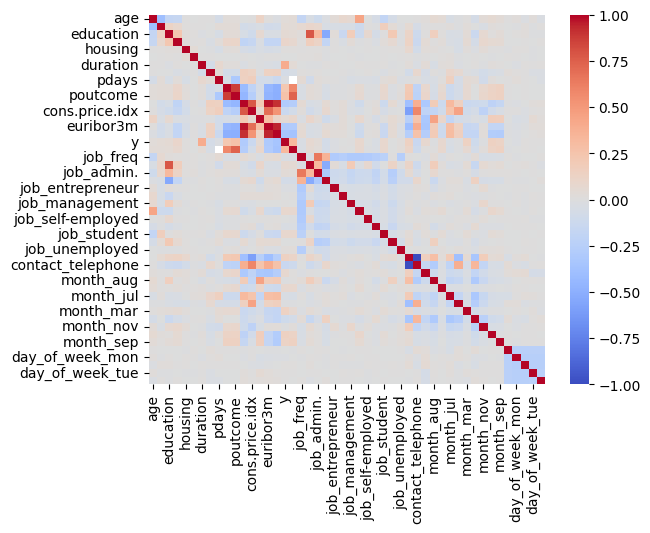

In [13]:
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")

# Predicting Customer Conversion (Yes/No) - Classification

In [16]:
print(df.columns)
print(df['age_bin'].isnull().sum())

Index(['age', 'marital', 'education', 'default', 'housing', 'loan', 'duration',
       'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y',
       'was_contacted', 'age_bin', 'job_freq', 'education_target',
       'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'contact_cellular',
       'contact_telephone', 'month_apr', 'month_aug', 'month_dec', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep', 'day_of_week_fri', 'day_of_week_mon', 'day_of_week_thu',
       'day_of_week_tue', 'day_of_week_wed'],
      dtype='object')
20285


In [17]:
X = df.drop(columns=['y', 'default', 'pdays', 'age_bin'])  # Features
y = df['y']  # Target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Logistic Regression works better with normalized data)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Predict
y_pred = log_reg.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9110897347808162
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      6472
           1       0.64      0.45      0.53       805

    accuracy                           0.91      7277
   macro avg       0.79      0.71      0.74      7277
weighted avg       0.90      0.91      0.90      7277



In [22]:
# Initialize with class weighting
rf = RandomForestClassifier(
    n_estimators=200,          # More trees = better performance (but slower)
    class_weight='balanced',   # Adjusts for imbalanced classes
    max_depth=10,              # Prevents overfitting
    random_state=42,
    n_jobs=-1                  # Uses all CPU cores
)

# Train
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]  # Probabilities for ROC-AUC

# Metrics
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

              precision    recall  f1-score   support

           0       0.98      0.87      0.92      6472
           1       0.46      0.89      0.60       805

    accuracy                           0.87      7277
   macro avg       0.72      0.88      0.76      7277
weighted avg       0.93      0.87      0.89      7277

ROC-AUC: 0.943


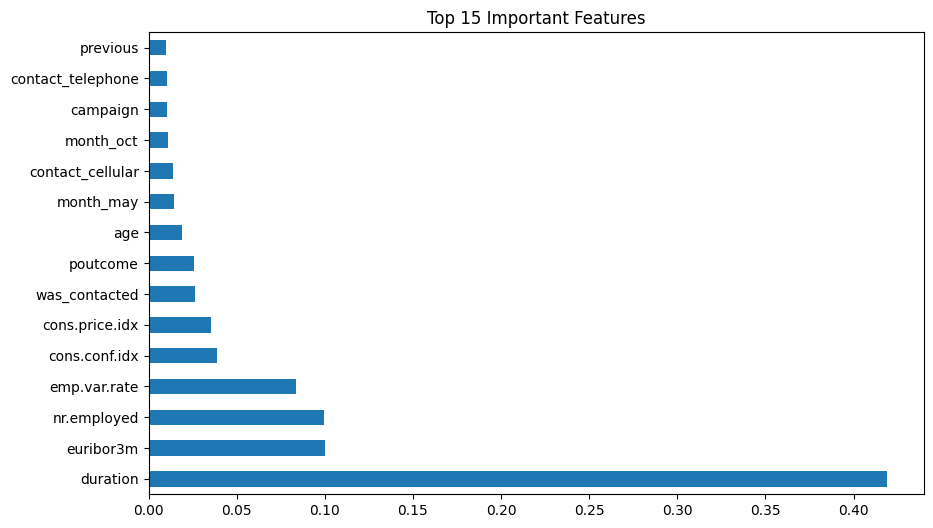

In [23]:
# Get feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
top_features.plot(kind='barh')
plt.title('Top 15 Important Features')
plt.show()